<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA_Accelerated_SVG_PNG_to_Layout_PEC_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [3]:
# -*- coding: utf-8 -*-
"""CUDA-Accelerated Layout Generation with OPC and PEC.

This script performs Optical Proximity Correction (OPC) and E-beam Proximity
Effect Correction (PEC) on a user-provided SVG or PNG layout. It utilizes
CUDA acceleration (via CuPy) for FFT convolutions and Monte Carlo simulations.
"""

!nvidia-smi

Tue Jan 13 01:09:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   54C    P0             29W /   72W |     271MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

CuPy is already installed.


Saving googlelogo_clr_74x24px.svg to googlelogo_clr_74x24px (1).svg
Pixel Size: 11.72 nm
Running Optical Proximity Correction (OPC)...
Running E-beam Proximity Effect Correction (PEC)...
Running E-beam Monte Carlo Simulation...


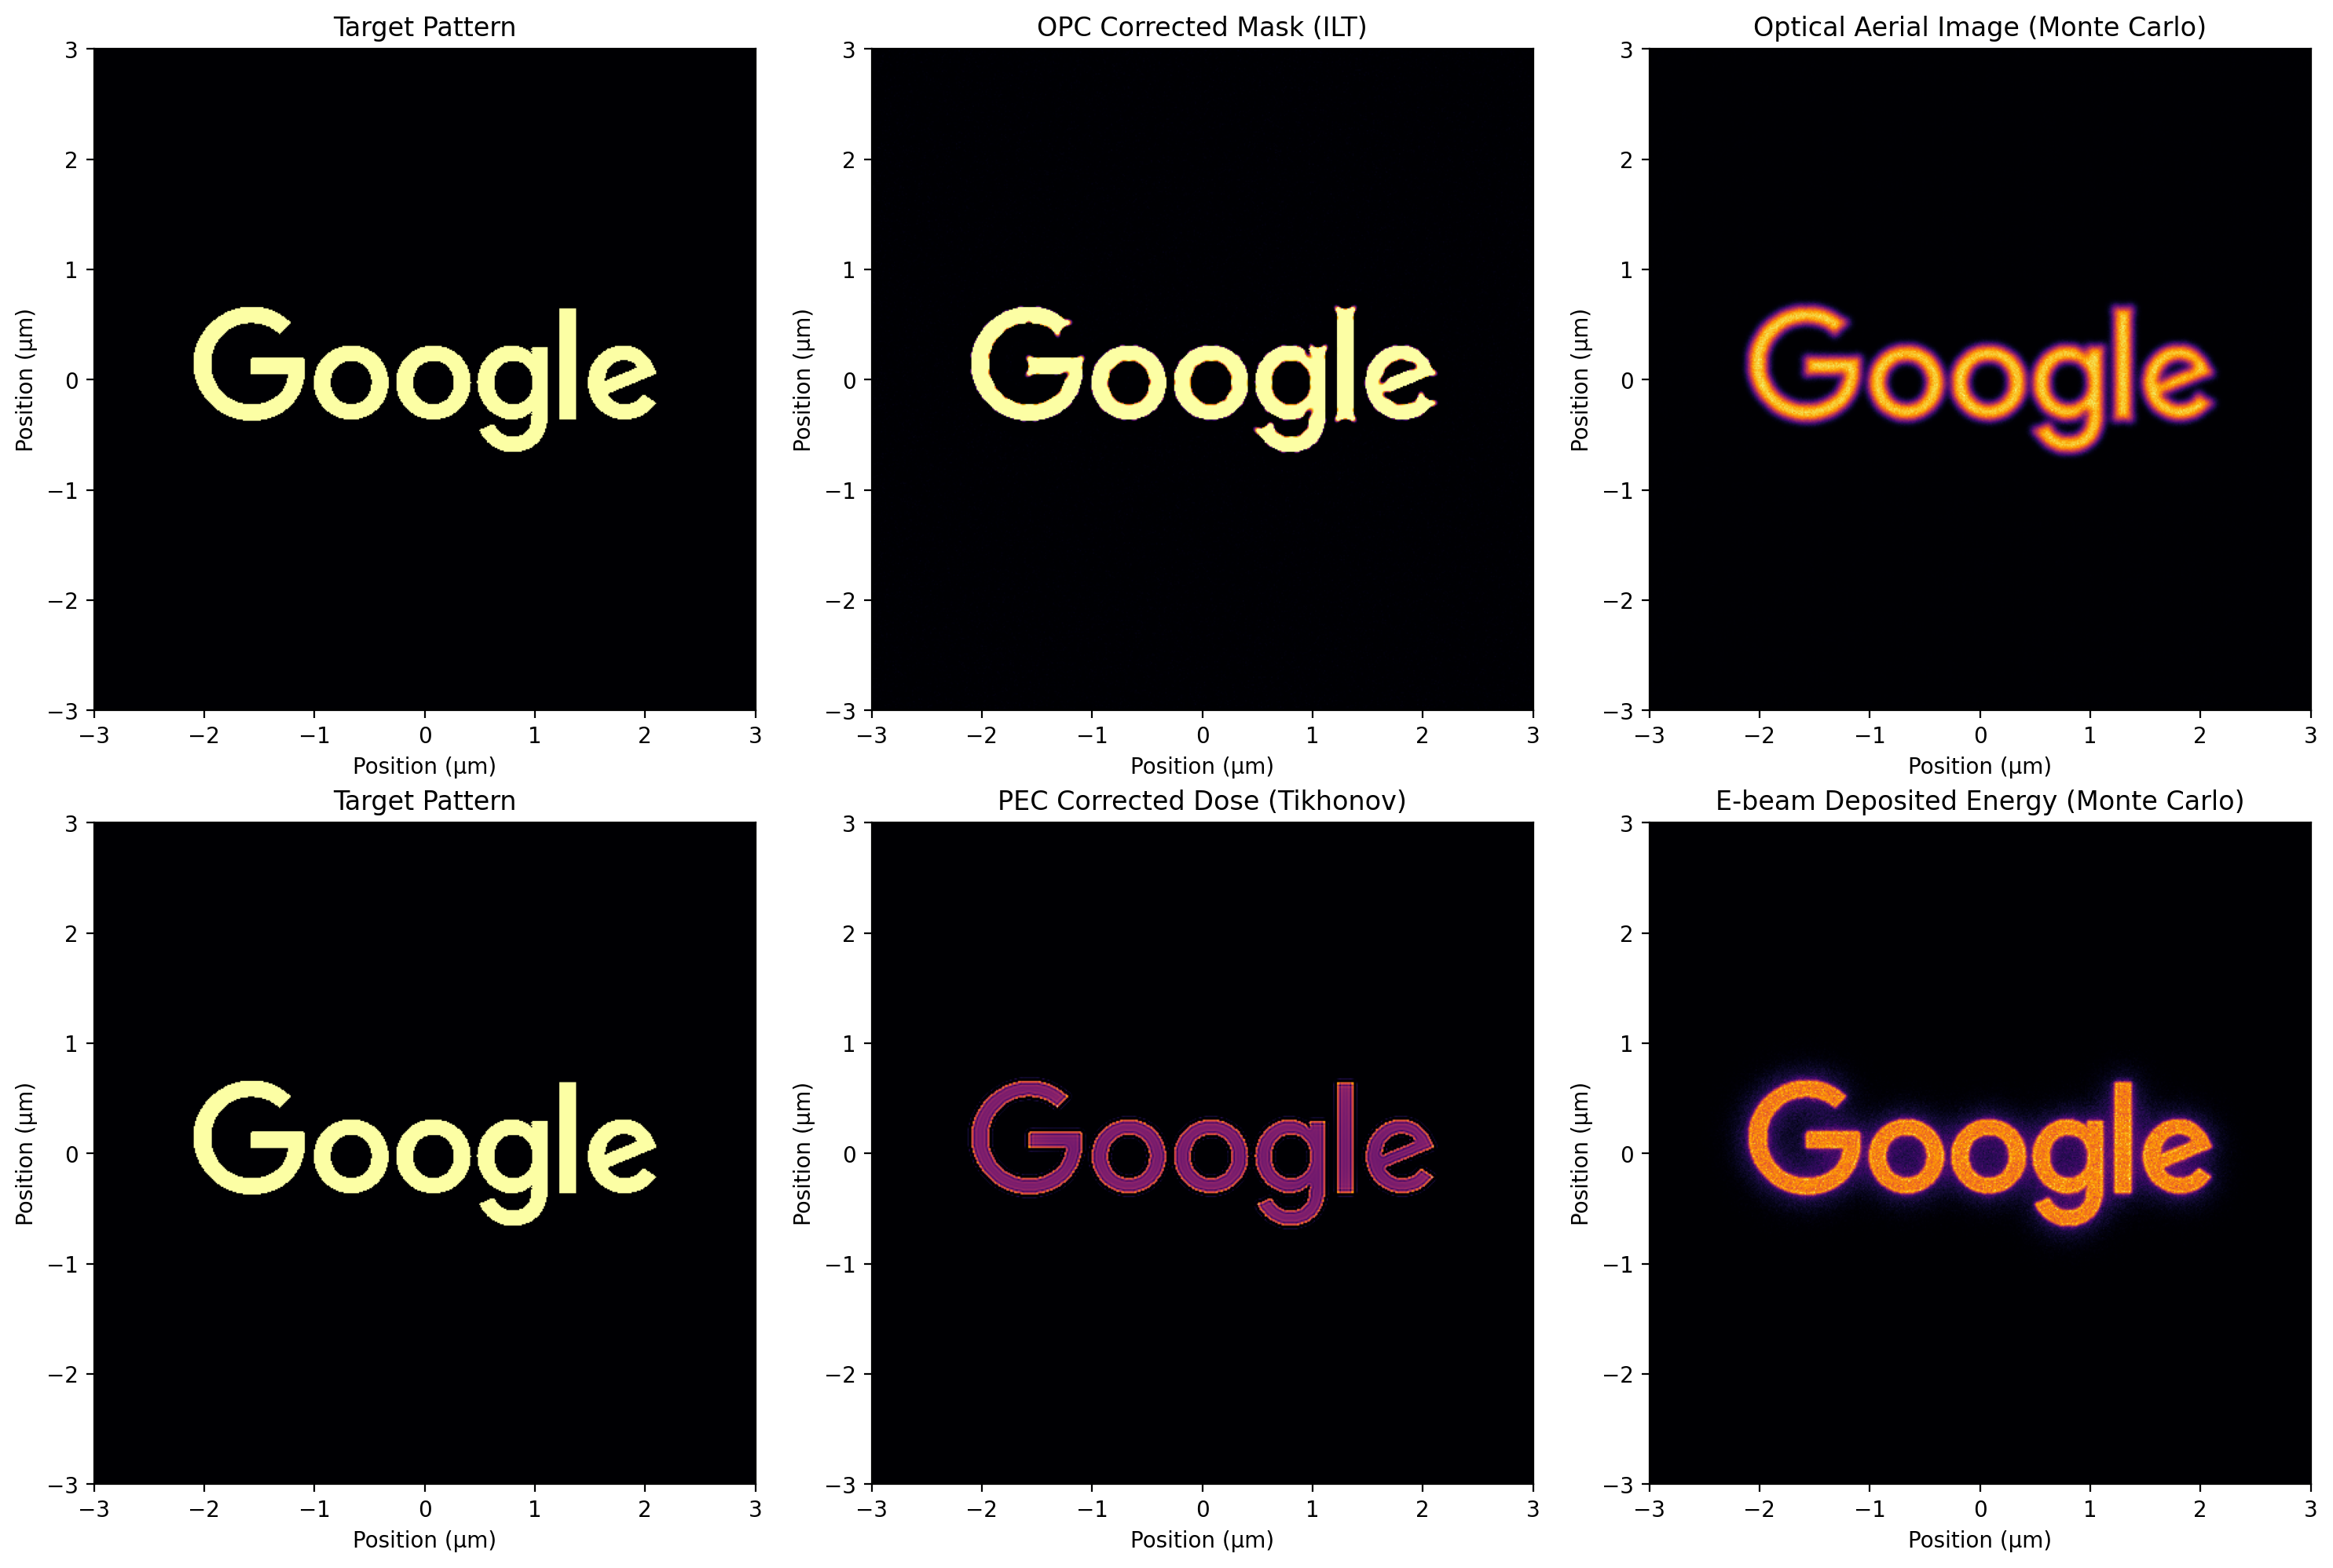

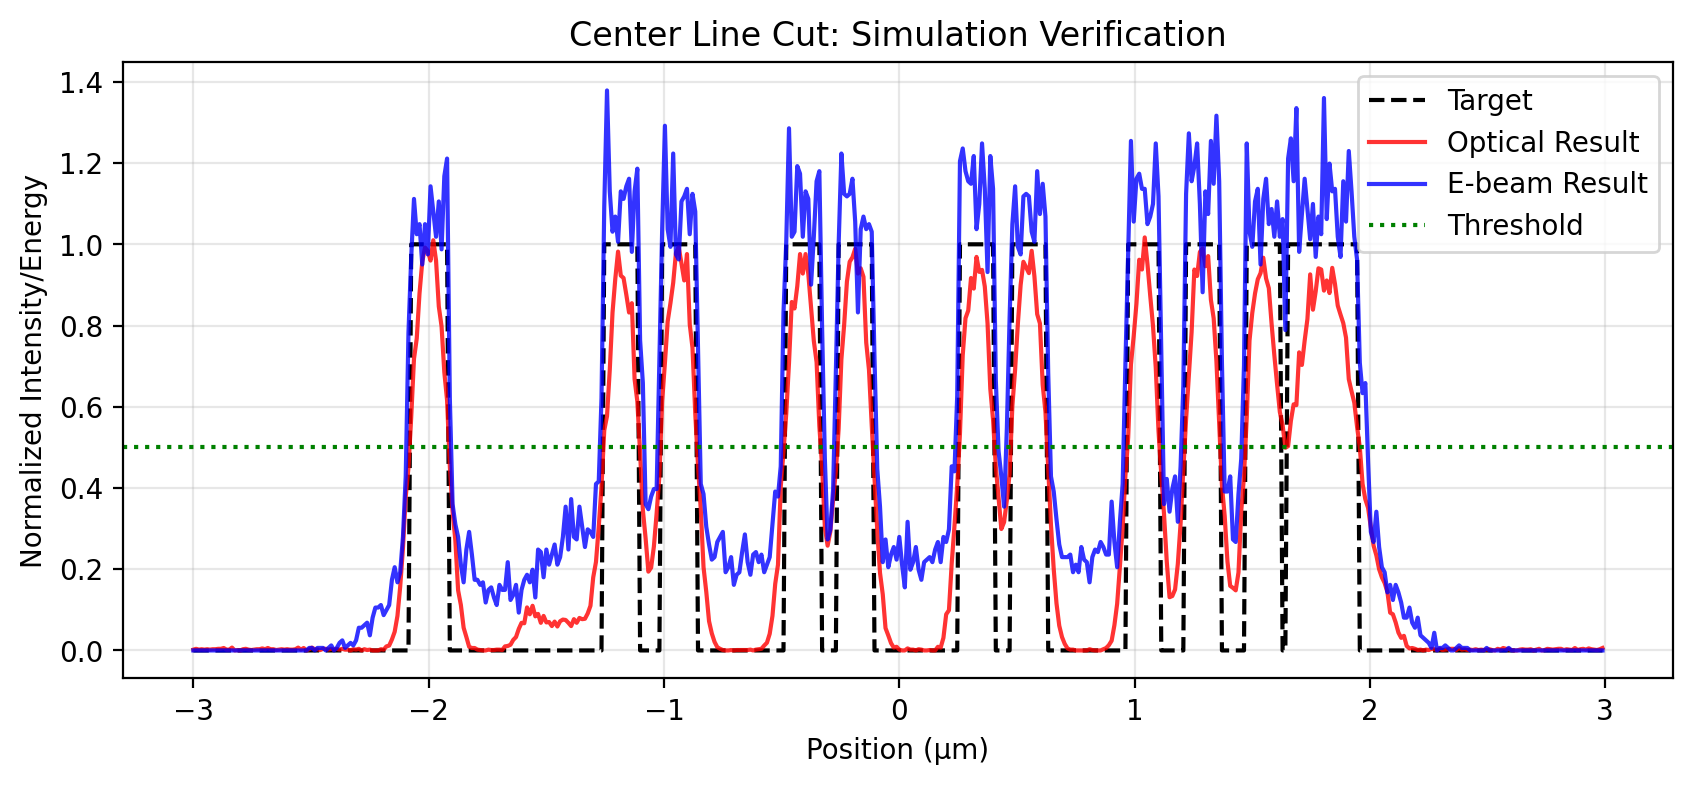

In [4]:
import io
import os
import re
import sys
import subprocess
from dataclasses import dataclass
from typing import Tuple, Dict

# --- Environment Setup (Colab Specifics) ---
def _install_dependencies() -> None:
    """Check for CUDA and install necessary system/Python libraries."""
    try:
        import cupy  # noqa: F401
        print("CuPy is already installed.")
    except ImportError:
        print("Detecting CUDA version and installing dependencies...")
        # Detect CUDA version
        cuda_major = 12  # Default
        try:
            out = subprocess.check_output(["nvidia-smi"], text=True)
            match = re.search(r"CUDA Version:\s+(\d+)\.", out)
            if match:
                cuda_major = int(match.group(1))
        except Exception:
            pass

        cupy_pkg = f"cupy-cuda{cuda_major}x"
        print(f"Installing {cupy_pkg}, cairosvg, and pillow...")

        # Install system libs for Cairo (SVG rendering)
        subprocess.check_call(["bash", "-lc", "apt-get -y update -qq"])
        subprocess.check_call([
            "bash", "-lc",
            "apt-get -y install -qq libcairo2 libpango-1.0-0 libpangocairo-1.0-0"
        ])

        # Install Python packages
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", cupy_pkg])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pillow", "cairosvg"])
        print("Installation complete.")

_install_dependencies()

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import cupy as cp
import cairosvg
from google.colab import files

# --- Configuration & Control Knobs ---

# Set Matplotlib DPI as requested
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "image.cmap": "inferno",
})

@dataclass(frozen=True)
class SimConfig:
    """Simulation configuration parameters (Control Knobs)."""

    # --- Domain Setup ---
    domain_width_um: float = 6.0          # Total simulation width in microns
    grid_n: int = 512                     # Simulation grid size (NxN)
    shape_fill_fraction: float = 0.70     # Target fill size relative to canvas

    # --- Input Processing ---
    alpha_threshold: float = 0.15         # Cutoff for input transparency
    binarize_target: bool = True          # Force hard binary target mask

    # --- Optical Lithography (OPC) ---
    opt_sigma_nm: float = 35.0            # Optical Gaussian blur sigma
    opt_threshold: float = 0.50           # Resist clearing threshold
    opt_photons_per_pixel: float = 1000.0 # Shot noise level

    # OPC Optimization Parameters
    opt_opc_iters: int = 80               # Gradient descent iterations
    opt_opc_step: float = 0.50            # Gradient descent step size
    opt_sigmoid_slope: float = 0.08       # Steepness of sigmoid for optimization

    # --- E-beam Lithography (PEC) ---
    eb_sigma_f_nm: float = 12.0           # Forward scattering sigma (blur)
    eb_sigma_b_nm: float = 140.0          # Backscattering sigma (proximity effect)
    eb_eta: float = 0.40                  # Backscattering ratio (energy in tail)
    eb_threshold: float = 0.50            # Resist clearing threshold

    # PEC Optimization Parameters
    eb_reg_lambda: float = 5.0e-3         # Tikhonov regularization factor
    eb_dose_clip: float = 5.0             # Max allowed dose multiplier

    # --- Monte Carlo & System ---
    mc_electrons_total: int = 3_000_000   # Total electrons for simulation
    mc_chunk_size: int = 500_000          # Batch size for GPU memory management
    seed: int = 42                        # Random seed for reproducibility


CFG = SimConfig()

# --- Utility Functions ---

def domain_width_nm(cfg: SimConfig) -> float:
    """Convert domain width to nanometers."""
    return float(cfg.domain_width_um) * 1000.0

def pixel_nm(cfg: SimConfig) -> float:
    """Calculate pixel size in nanometers."""
    return domain_width_nm(cfg) / float(cfg.grid_n)

def gaussian_psf(shape: Tuple[int, int], sigma_px: float) -> cp.ndarray:
    """Generate a centered 2D Gaussian Point Spread Function."""
    ny, nx = shape
    y = cp.arange(ny) - ny // 2
    x = cp.arange(nx) - nx // 2
    yy, xx = cp.meshgrid(y, x, indexing="ij")
    psf = cp.exp(-(xx**2 + yy**2) / (2.0 * float(sigma_px)**2))
    return (psf / cp.sum(psf)).astype(cp.float32)

def double_gaussian_psf(
    shape: Tuple[int, int],
    sigma_f_px: float,
    sigma_b_px: float,
    eta: float
) -> cp.ndarray:
    """Generate a mixture of two Gaussians (Point Spread Function)."""
    psf_f = gaussian_psf(shape, sigma_f_px)
    psf_b = gaussian_psf(shape, sigma_b_px)
    psf = (1.0 - float(eta)) * psf_f + float(eta) * psf_b
    return (psf / cp.sum(psf)).astype(cp.float32)

def fft_convolve2d(img: cp.ndarray, psf_f: cp.ndarray) -> cp.ndarray:
    """Perform 2D convolution via FFT."""
    out = cp.fft.ifft2(cp.fft.fft2(img) * psf_f)
    return cp.real(out).astype(cp.float32)

# --- Input Handling ---

def load_and_process_image(cfg: SimConfig) -> Tuple[cp.ndarray, cp.ndarray]:
    """
    Prompt user to upload an image, process it, and return GPU arrays.

    Returns:
        Tuple[target_mask, psf_f_optical, psf_f_ebeam]
    """
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No file uploaded.")

    filename = next(iter(uploaded.keys()))
    ext = os.path.splitext(filename)[1].lower().strip()

    # Load Image
    if ext == ".svg":
        with open(filename, "rb") as f:
            svg_bytes = f.read()
        png_bytes = cairosvg.svg2png(bytestring=svg_bytes, output_width=2048)
        img = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
    else:
        img = Image.open(filename).convert("RGBA")

    # Extract Alpha and Center
    arr = np.asarray(img)
    alpha = arr[:, :, 3].astype(np.float32) / 255.0

    # Bounding Box Crop
    ys, xs = np.where(alpha > cfg.alpha_threshold)
    if len(ys) == 0:
        raise ValueError("Image is fully transparent.")

    alpha_crop = alpha[ys.min():ys.max()+1, xs.min():xs.max()+1]

    # Resize to Fit Grid
    max_dim = int(cfg.grid_n * cfg.shape_fill_fraction)
    pil_crop = Image.fromarray((alpha_crop * 255).astype(np.uint8))

    # Preserve aspect ratio
    w, h = pil_crop.size
    scale = min(max_dim / w, max_dim / h)
    new_size = (int(w * scale), int(h * scale))
    pil_resized = pil_crop.resize(new_size, Image.Resampling.LANCZOS)

    # Place on Canvas
    target_cpu = np.zeros((cfg.grid_n, cfg.grid_n), dtype=np.float32)
    mask = np.array(pil_resized).astype(np.float32) / 255.0

    y_off = (cfg.grid_n - new_size[1]) // 2
    x_off = (cfg.grid_n - new_size[0]) // 2
    target_cpu[y_off:y_off+new_size[1], x_off:x_off+new_size[0]] = mask

    if cfg.binarize_target:
        target_cpu = (target_cpu > cfg.alpha_threshold).astype(np.float32)

    return cp.asarray(target_cpu)

# --- Simulation Logic ---

def run_optical_correction(
    target: cp.ndarray,
    cfg: SimConfig,
    psf_f: cp.ndarray
) -> Tuple[cp.ndarray, cp.ndarray]:
    """
    Perform OPC using gradient-descent ILT.

    Returns:
        Tuple[corrected_mask, simulated_print]
    """
    print("Running Optical Proximity Correction (OPC)...")

    # Initial Guess: The target itself
    mask = target.copy()

    # Add slight noise to break symmetry for faster convergence
    rng = cp.random.default_rng(cfg.seed)
    mask += 0.01 * rng.standard_normal(mask.shape, dtype=cp.float32)
    mask = cp.clip(mask, 0.0, 1.0)

    # Gradient Descent
    for _ in range(cfg.opt_opc_iters):
        aerial = fft_convolve2d(mask, psf_f)

        # Soft sigmoid approximation of the printing process
        diff = (aerial - cfg.opt_threshold) / cfg.opt_sigmoid_slope
        printed_soft = 1.0 / (1.0 + cp.exp(-diff))

        # Error term
        error = printed_soft - target

        # Gradient chain rule
        grad = error * (printed_soft * (1.0 - printed_soft)) / cfg.opt_sigmoid_slope
        grad_mask = fft_convolve2d(grad, psf_f) # Approximate adjoint

        # Update
        mask = cp.clip(mask - cfg.opt_opc_step * grad_mask, 0.0, 1.0)

    # Final Verification (Monte Carlo)
    expected = fft_convolve2d(mask, psf_f)
    lam = cp.clip(expected * cfg.opt_photons_per_pixel, 0.0, None)
    noisy = rng.poisson(lam).astype(cp.float32) / cfg.opt_photons_per_pixel

    return mask, noisy

def run_ebeam_correction(
    target: cp.ndarray,
    cfg: SimConfig,
    psf_f: cp.ndarray,
    sigma_f_px: float,
    sigma_b_px: float
) -> Tuple[cp.ndarray, cp.ndarray]:
    """
    Perform PEC using Tikhonov Regularization (Deconvolution).

    Returns:
        Tuple[corrected_dose_map, simulated_energy_deposition]
    """
    print("Running E-beam Proximity Effect Correction (PEC)...")

    # 1. Calculate Corrected Dose (Inverse Filter)
    target_f = cp.fft.fft2(target)

    # Wiener/Tikhonov Deconvolution: D = T * conj(H) / (|H|^2 + lambda)
    denom = (cp.abs(psf_f)**2) + cfg.eb_reg_lambda
    dose_f = target_f * cp.conj(psf_f) / denom

    dose = cp.real(cp.fft.ifft2(dose_f))
    dose = cp.clip(dose, 0.0, cfg.eb_dose_clip) # Physical constraints

    # 2. Monte Carlo Verification
    print("Running E-beam Monte Carlo Simulation...")
    # Normalize dose to probability distribution
    dose_flat = dose.ravel()
    dose_sum = float(cp.sum(dose_flat))

    if dose_sum == 0:
        return dose, cp.zeros_like(dose)

    cdf = cp.cumsum(dose_flat)
    cdf_max = cdf[-1]

    rng = cp.random.default_rng(cfg.seed)
    energy_acc = cp.zeros(dose.size, dtype=cp.int32)

    n_processed = 0
    while n_processed < cfg.mc_electrons_total:
        batch = min(cfg.mc_chunk_size, cfg.mc_electrons_total - n_processed)

        # Determine landing pixels based on Dose Map
        u = rng.random(batch, dtype=cp.float32) * cdf_max
        indices = cp.searchsorted(cdf, u).astype(cp.int32)

        y0 = indices // cfg.grid_n
        x0 = indices % cfg.grid_n

        # Apply Scattering
        is_backscatter = rng.random(batch) < cfg.eb_eta
        sigmas = cp.where(is_backscatter, sigma_b_px, sigma_f_px)

        dy = rng.standard_normal(batch) * sigmas
        dx = rng.standard_normal(batch) * sigmas

        y_final = cp.clip(y0 + cp.rint(dy).astype(cp.int32), 0, cfg.grid_n - 1)
        x_final = cp.clip(x0 + cp.rint(dx).astype(cp.int32), 0, cfg.grid_n - 1)

        # Histogram
        flat_indices = y_final * cfg.grid_n + x_final
        cp.add.at(energy_acc, flat_indices, 1)

        n_processed += batch

    # Normalize Energy: (Counts / Total Electrons) * Total Dose Weight
    # This ensures the units match the convolution model "Expected Energy"
    energy_mc = energy_acc.astype(cp.float32) / cfg.mc_electrons_total * dose_sum
    energy_mc = energy_mc.reshape((cfg.grid_n, cfg.grid_n))

    return dose, energy_mc

# --- Main Execution Flow ---

# 1. Load Data
target_gpu = load_and_process_image(CFG)

# 2. Prepare PSFs
px_size = pixel_nm(CFG)
print(f"Pixel Size: {px_size:.2f} nm")

# Optical PSF
psf_opt = gaussian_psf((CFG.grid_n, CFG.grid_n), CFG.opt_sigma_nm / px_size)
psf_opt_f = cp.fft.fft2(cp.fft.ifftshift(psf_opt))

# E-beam PSF
psf_eb = double_gaussian_psf(
    (CFG.grid_n, CFG.grid_n),
    CFG.eb_sigma_f_nm / px_size,
    CFG.eb_sigma_b_nm / px_size,
    CFG.eb_eta
)
psf_eb_f = cp.fft.fft2(cp.fft.ifftshift(psf_eb))

# 3. Run Simulations
# Optical
opc_mask, opc_result = run_optical_correction(target_gpu, CFG, psf_opt_f)

# E-beam
pec_dose, pec_result = run_ebeam_correction(
    target_gpu,
    CFG,
    psf_eb_f,
    CFG.eb_sigma_f_nm / px_size,
    CFG.eb_sigma_b_nm / px_size
)

# --- Visualization ---

def plot_results(
    target: cp.ndarray,
    opc_mask: cp.ndarray,
    opc_res: cp.ndarray,
    pec_dose: cp.ndarray,
    pec_res: cp.ndarray,
    cfg: SimConfig
) -> None:
    """Visualize inputs, corrections, and results."""
    cpu_target = cp.asnumpy(target)
    cpu_opc_mask = cp.asnumpy(opc_mask)
    cpu_opc_res = cp.asnumpy(opc_res)
    cpu_pec_dose = cp.asnumpy(pec_dose)
    cpu_pec_res = cp.asnumpy(pec_res)

    extent = [-cfg.domain_width_um/2, cfg.domain_width_um/2,
              -cfg.domain_width_um/2, cfg.domain_width_um/2]

    fig, ax = plt.subplots(2, 3, figsize=(15, 10))

    # Row 1: Optical
    ax[0, 0].imshow(cpu_target, extent=extent)
    ax[0, 0].set_title("Target Pattern")

    ax[0, 1].imshow(cpu_opc_mask, extent=extent)
    ax[0, 1].set_title("OPC Corrected Mask (ILT)")

    ax[0, 2].imshow(cpu_opc_res, extent=extent)
    ax[0, 2].set_title("Optical Aerial Image (Monte Carlo)")

    # Row 2: E-beam
    ax[1, 0].imshow(cpu_target, extent=extent)
    ax[1, 0].set_title("Target Pattern")

    ax[1, 1].imshow(cpu_pec_dose, extent=extent)
    ax[1, 1].set_title("PEC Corrected Dose (Tikhonov)")

    ax[1, 2].imshow(cpu_pec_res, extent=extent)
    ax[1, 2].set_title("E-beam Deposited Energy (Monte Carlo)")

    for a in ax.flat:
        a.set_xlabel("Position (μm)")
        a.set_ylabel("Position (μm)")

    plt.tight_layout()
    plt.show()

    # Line Cuts
    mid = cfg.grid_n // 2
    x_axis = (np.arange(cfg.grid_n) - mid) * (pixel_nm(cfg) / 1000.0) # um

    plt.figure(figsize=(10, 4))
    plt.plot(x_axis, cpu_target[mid, :], 'k--', label="Target")
    plt.plot(x_axis, cpu_opc_res[mid, :], 'r-', alpha=0.8, label="Optical Result")
    plt.plot(x_axis, cpu_pec_res[mid, :], 'b-', alpha=0.8, label="E-beam Result")
    plt.axhline(cfg.opt_threshold, color='g', linestyle=':', label="Threshold")
    plt.title("Center Line Cut: Simulation Verification")
    plt.xlabel("Position (μm)")
    plt.ylabel("Normalized Intensity/Energy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_results(target_gpu, opc_mask, opc_result, pec_dose, pec_result, CFG)